# Variational Autoencoder (VAE)

Useful links: 
* Original paper http://arxiv.org/abs/1312.6114
* Helpful videos explaining the topic 
   * https://www.youtube.com/watch?v=P78QYjWh5sM     
   * http://videolectures.net/deeplearning2015_courville_autoencoder_extension/?q=aaron%20courville

### Download data

In [1]:
#!L
from yfile import download_from_yadisk
import os

TARGET_DIR = '.'
FILENAME = "celeba.zip"

if not os.path.exists(os.path.join(TARGET_DIR, FILENAME)):
    # we are going to download 1.4 gb file, downloading will take some time (8-10 minutes)
    download_from_yadisk(
        short_url='https://disk.yandex.ru/d/QErNx-MoC-2Y6Q',
        filename=FILENAME,
        target_dir=TARGET_DIR
    )

    # alternative way: 
    #from gfile import download_list
    #download_list(url=https://drive.google.com/file/d/1lwn2JMwWNGloGvyzKUOcewT8JqP1ICoW,
    #               filename=FILENAME, target_dir=TARGET_DIR)

filesize = os.path.getsize(os.path.join(TARGET_DIR, FILENAME))
GB = 2**30
assert filesize > 1 * GB, "{filesize} is too small, something wrong with downloading"

In [ ]:
#!L:bash
!unzip celeba.zip

## Prepare the data

In [1]:
#!L
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.utils import make_grid

device = torch.device("cuda:4") if torch.cuda.is_available() else torch.device('cpu')

In [2]:
#!L
class CropCelebA64:
    
    def __call__(self, pic):
        new_pic = pic.crop((15, 40, 178 - 15, 218 - 30))
        return new_pic

    def __repr__(self):
        return self.__class__.__name__ + '()'

In [3]:
#!L

# Note that for simplicity we reduce the number of channels to 1
# But if you want to be hardcore feel free to comment .Grayscale :)

train_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='train',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        
        torchvision.transforms.Grayscale()
    ]),
    #download=True,   # in case of problems with downloading from gdrive above
)

validation_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='valid',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.ToTensor(),
        
        torchvision.transforms.Grayscale()
    ]),
)

In [12]:
#!L
# Save first 10k images for evaluation
num_images = 10000
real_images_tensor = torch.stack([train_dataset[i][0] for i in range(num_images)], dim=0)
real_images = real_images_tensor.data.numpy().transpose([0, 2, 3, 1])
np.savez("real.npz", Pictures=real_images.reshape(num_images, 64 * 64 * 1))

In [13]:
real_images.shape

(10000, 64, 64, 1)

In [4]:
#!L
BATCH_SIZE = 512

# you may find useful parameters `num_workers` and `pin_memory`
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=32, pin_memory=True)
val_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, num_workers=32, pin_memory=True)

# Autoencoder

Why to use all this complicated formulaes and regularizations, what is the need for variational inference? To analyze the difference, let's first train just an autoencoder on the data:

In [44]:
#!L
dimZ = 512  # Considering face reconstruction task, which size of representation seems reasonable?

# Define the decoder and encoder as networks with one hidden fc-layer
# (that means you will have 2 fc layers in each net)
# Use ReLU for hidden layers' activations
# GlorotUniform initialization for W
# Zero initialization for biases
# It's also convenient to put sigmoid activation on output layer to get nice normalized pics

import torch
import torch.nn as nn
import torch.nn.functional as F

class EncoderAE(nn.Module):
    def __init__(
        self,
        img_size=64,
        in_channels=1,
        hidden_dim=512,
        latent_dim=128,
    ):
        super().__init__()
        
        self.flatten = nn.Flatten()
        self.fc_1 = nn.Linear(img_size * img_size * in_channels, hidden_dim)
        self.act = nn.ReLU()
        self.fc_2 = nn.Linear(hidden_dim, latent_dim)
        self.sigmoid = nn.Sigmoid()

        nn.init.xavier_uniform_(self.fc_1.weight)
        nn.init.xavier_uniform_(self.fc_2.weight)

        nn.init.zeros_(self.fc_1.bias)
        nn.init.zeros_(self.fc_2.bias)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc_1(x)
        x = self.act(x)
        x = self.fc_2(x)
        return self.sigmoid(x)


class DecoderAE(nn.Module):
    def __init__(
        self,
        latent_dim=128,
        out_channels=1,
        hidden_dim=512,
        output_size=64,
    ):
        super().__init__()
        self.output_size = output_size
        self.out_channels = out_channels

        self.fc_1 = nn.Linear(latent_dim, hidden_dim)
        self.act = nn.ReLU()
        self.fc_2 = nn.Linear(hidden_dim, output_size * output_size * out_channels)

        nn.init.xavier_uniform_(self.fc_1.weight)
        nn.init.xavier_uniform_(self.fc_2.weight)

        nn.init.zeros_(self.fc_1.bias)
        nn.init.zeros_(self.fc_2.bias)

    def forward(self, z):
        z = self.fc_1(z)
        z = self.act(z)
        z = self.fc_2(z)
        return z.view(-1, self.out_channels, self.output_size, self.output_size)


class Autoencoder(nn.Module):
    
    def __init__(self, encoder: EncoderAE, decoder: DecoderAE):
        super(Autoencoder, self).__init__()

        # TODO

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):

        # TODO

        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)

        return reconstruction, latent_code

In [48]:
#!L
# Create MSE loss function
criterion = torch.nn.MSELoss()
encoder = EncoderAE(latent_dim=dimZ, hidden_dim=3072)
decoder = DecoderAE(latent_dim=dimZ, hidden_dim=3072)
autoencoder = Autoencoder(encoder, decoder).to(device)

# Use Adam optimizer
optimizer = optim.AdamW(autoencoder.parameters(), lr=1e-3)

In [49]:
# Train your autoencoder
# Visualize progress in reconstruction and loss decay
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm


def plot_metrics_ae(train_losses, val_losses=None):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2 if val_losses is not None else 1, 1)
    plt.plot(train_losses, label='Train Loss')
    if val_losses:
        plt.plot(val_losses, label='Validation Loss')
    plt.title('Training Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

from IPython.display import clear_output, display


def train_loop_ae(
    model, 
    train_loader, 
    val_loader, 
    loss_function, 
    epochs=20, 
    device=device,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_losses, val_losses = [], []

    plt.ioff()
    loss_fig = plt.figure(figsize=(15, 5))
    sample_fig = plt.figure(figsize=(12, 6))
    recon_fig = plt.figure(figsize=(12, 6))
    plt.ion()
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_train_loss = 0
        batch_pbar = tqdm(
            enumerate(train_loader),
            total=len(train_loader),
            desc=f'Epoch {epoch}/{epochs}',
            leave=False
        )
        
        for batch_idx, (data, _) in batch_pbar:
            data = data.to(device)
            optimizer.zero_grad()
            
            recon_batch, _ = model(data)
            loss = loss_function(recon_batch, data)
            
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        train_losses.append(epoch_train_loss/len(train_loader.dataset))

        if val_loader:
            model.eval()
            val_loss = 0
            
            with torch.no_grad():
                for val_data, _ in val_loader:
                    val_data = val_data.to(device)
                    recon_val, _ = model(val_data)
                    
                    val_loss += loss_function(recon_val, val_data).item()
            
            val_losses.append(val_loss/len(val_loader.dataset))

        if epoch % 1 == 0 or epoch == epochs:
            clear_output(wait=True)
            loss_fig.clf()
            ax1 = loss_fig.add_subplot(111)
            
            ax1.plot(range(1, epoch+1), train_losses, label='Train Loss')
            if val_loader:
                ax1.plot(range(1, epoch+1), val_losses, label='Val Loss')
            ax1.set_title('Training Progress')
            ax1.set_xlabel('Epoch')
            ax1.set_ylabel('Loss')
            ax1.legend()
            ax1.grid(True)
            
            loss_fig.tight_layout()
            display(loss_fig)

            with torch.no_grad():
                samples = generate_ae(model, batch_size=16, device=device)
                sample_fig.clf()
                plt.figure(sample_fig.number)
                grid = make_grid(samples, nrow=8, normalize=True)
                plt.imshow(grid.permute(1, 2, 0).clip(0, 1))
                plt.title(f'Generated Samples - Epoch {epoch}')
                plt.axis('off')
                display(sample_fig)

                sample_batch = next(iter(train_loader))[0][:8].to(device)
                reconstructions = reconstruct_ae(model, sample_batch, device)
                recon_fig.clf()
                plt.figure(recon_fig.number)
                comparison = make_grid(torch.cat([sample_batch.cpu(), reconstructions]), nrow=8, normalize=True)
                plt.imshow(comparison.permute(1, 2, 0).clip(0, 1))
                plt.title(f'Original (top) vs Reconstructed (bottom) - Epoch {epoch}')
                plt.axis('off')
                display(recon_fig)

            print(f'Epoch {epoch}/{epochs}')
            print(f'Train Loss: {train_losses[-1]:.4f}')
            if val_loader:
                print(f'Val Loss: {val_losses[-1]:.4f}')
    
    return train_losses, val_losses

def generate_ae(model, batch_size=16, device=device):
    model.eval()
    with torch.no_grad():
        latent_dim = model.encoder.fc_2.out_features
        z = torch.randn(batch_size, latent_dim).to(device)
        samples = model.decoder(z).cpu()
    return samples

def reconstruct_ae(model, img_batch, device=device):
    model.eval()
    with torch.no_grad():
        img_batch = img_batch.to(device)
        recon_batch, _ = model(img_batch)
    return recon_batch.cpu()

def visualize_images_ae(images, title="", nrow=8):
    grid = make_grid(images, nrow=nrow)
    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

def mse_loss(recon_x, x):
    return F.mse_loss(recon_x, x, reduction='sum')

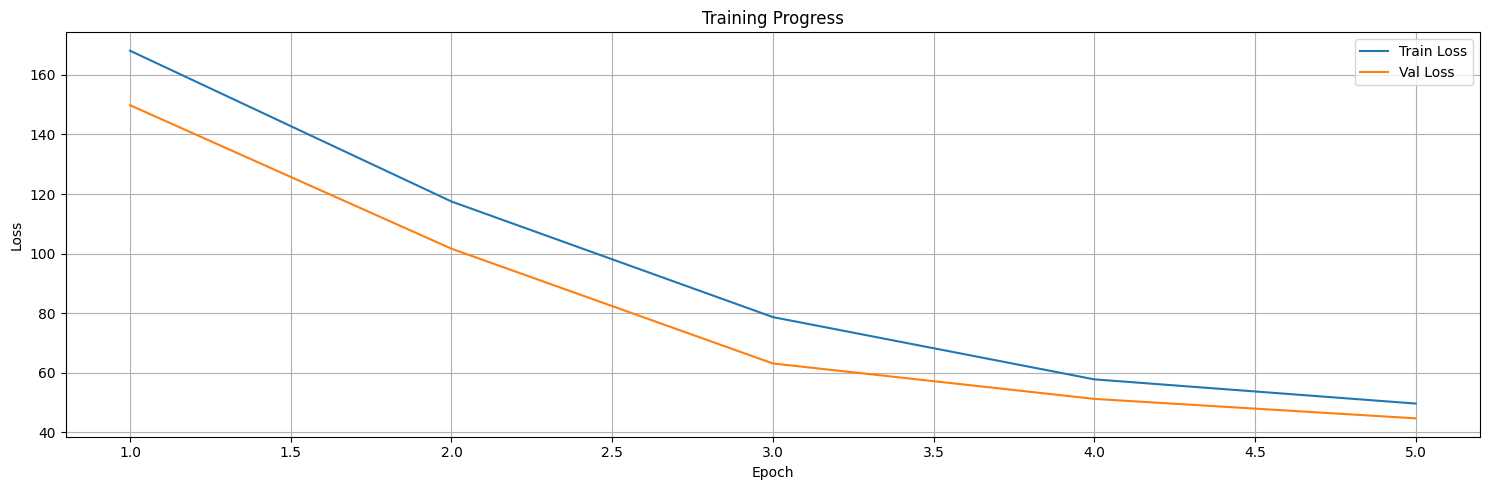

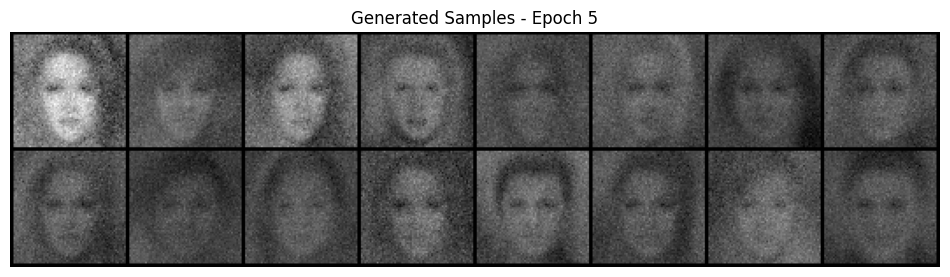

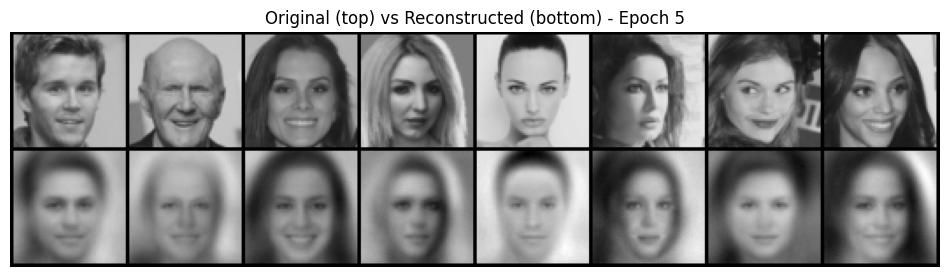

Epoch 5/5
Train Loss: 49.6262
Val Loss: 44.6641


In [50]:
train_losses, val_losses = train_loop_ae(
    model=autoencoder,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=mse_loss, 
    epochs=5,
    device=device
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12161019..1.1117451].


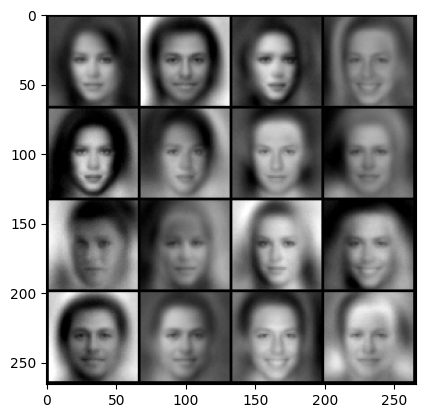

In [61]:
#!L
# Examine the reconstructions
from itertools import islice

images, _ = list(islice(val_loader, 1))[0]
reconstruction, latent_code = autoencoder(images.to(device))

reconstruction = reconstruction[:16].cpu()
plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

Reconstruction is not bad, right? 

# Sampling

Let's now sample several latent vectors and perform inference from $z$, reconstruct an image given some random $z$ representations.

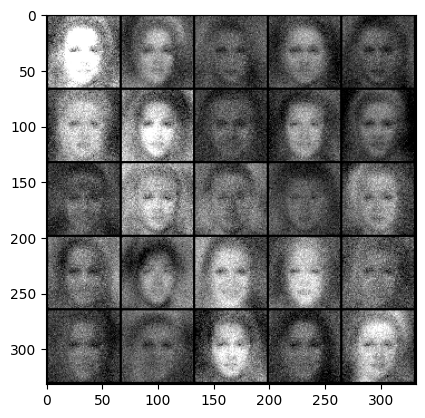

In [80]:
#!L
z = torch.randn(25, dimZ) * 0.18
reconstruction = autoencoder.decoder(z.to(device)).clip(0, 1)

plt.imshow(make_grid(reconstruction.cpu(), nrow=5).permute(1, 2, 0))

In [81]:
plt.show()

So, if we sample $z$ from normal, whould we eventually generate all possible faces? What do you think?

# Variational Autoencoder

Bayesian approach in deep learning considers everything in terms of distributions. Now our encoder generates not just a vector $z$ but posterior ditribution $q(z|x)$. In our case distribution $q$ is Gaussian distibution $N(\mu, \sigma)$ with parameters $\mu$, $\sigma$. Technically, the first difference is that you need to split bottleneck layer in two. One dense layer will generate vector $\mu$, and another will generate vector $\sigma$. Reparametrization trick should be implemented using the **gaussian_sampler** layer, that generates random vetor $\epsilon$ and returns $\mu+\sigma\epsilon \sim N(\mu, \sigma)$ .

Since our decoder is also a function that generates distribution, we need to do the same splitting for output layer. When testing the model we will look only on mean values, so one of the output will be actual autoencoder output.

In this homework we only ask for implementation of the simplest version of VAE - one $z$ sample per input. You can consider to sample several outputs from one input and average them.

In [5]:
#!L
# to compare with conventional AE, keep these hyperparameters
# or change them for the values that you used before
dimZ = 512

# define the network
# you can start from https://github.com/pytorch/examples/blob/master/vae/main.py
# or Theano-based examples here https://github.com/Lasagne/Recipes/blob/master/examples/variational_autoencoder/variational_autoencoder.py
# and here https://github.com/y0ast/Variational-Autoencoder/blob/master/VAE.py
# but remember that this is not your ground truth since the data is not MNIST
import torch
import torch.nn as nn
import torch.nn.functional as F

class EncoderVAE(nn.Module):
    def __init__(
        self,
        img_size=64,
        in_channels=1,
        hidden_dims=[32, 64, 128, 256],
        latent_dim=128,
        kernel_size=3,
        stride=2,
        padding=1,
        dropout=0.0,
        use_batchnorm=True
    ):
        super().__init__()
        
        self.latent_dim = latent_dim
        layers = []

        for i, h_dim in enumerate(hidden_dims):
            in_c = in_channels if i == 0 else hidden_dims[i-1]
            layers.append(nn.Conv2d(in_c, h_dim, kernel_size, stride, padding))
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(h_dim))
            layers.append(nn.Dropout2d(dropout))
        
        self.conv_blocks = nn.Sequential(*layers)
        self.final_size = img_size // (2 ** len(hidden_dims))
        self.out_features = hidden_dims[-1] * self.final_size ** 2

        self.fc_latent = nn.Linear(self.out_features, 2 * latent_dim)

    def forward(self, x):
        x = self.conv_blocks(x)
        x = torch.flatten(x, start_dim=1)
        mu_logvar = self.fc_latent(x)
        mu, logvar = mu_logvar.chunk(2, dim=1)
        return mu, logvar

class DecoderVAE(nn.Module):
    def __init__(
        self,
        latent_dim=128,
        out_channels=1,
        hidden_dims=[256, 128, 64, 32],
        output_size=64,
        kernel_size=3,
        stride=2,
        padding=1,
        dropout=0.0,
        use_batchnorm=True
    ):
        super().__init__()

        self.final_size = output_size // (2 ** len(hidden_dims))
        self.in_features = hidden_dims[0] * self.final_size ** 2

        self.fc = nn.Linear(latent_dim, self.in_features)

        layers = []
        for i in range(len(hidden_dims)-1):
            layers.append(
                nn.ConvTranspose2d(
                    hidden_dims[i], 
                    hidden_dims[i+1], 
                    kernel_size, 
                    stride, 
                    padding, 
                    output_padding=1
                )
            )
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(hidden_dims[i+1]))
            layers.append(nn.Dropout2d(dropout))

        layers.append(
            nn.ConvTranspose2d(
                hidden_dims[-1], 
                out_channels, 
                kernel_size, 
                stride, 
                padding, 
                output_padding=1
            )
        )
        self.deconv_blocks = nn.Sequential(*layers)
        self.hidden_dims = hidden_dims

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, self.hidden_dims[0], self.final_size, self.final_size)
        return torch.sigmoid(self.deconv_blocks(x))


class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def generate(self, num_samples=1, z=None, device=None):            
        if z is None:
            z = torch.randn(num_samples, self.encoder.fc_latent.out_features // 2, device=device)
        
        with torch.no_grad():
            samples = self.decoder(z)
        
        return samples.clamp(0, 1)
    

And the last, but not least! Place in the code where the most of the formulaes goes to - optimization objective. The objective for VAE has it's own name - variational lowerbound. And as for any lowerbound our intention is to maximize it. Here it is (for one sample $z$ per input $x$):

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z) \to max$$

Your next task is to implement two functions that compute KL-divergence and the second term - log-likelihood of an output. Here is some necessary math for your convenience:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$
$$\log p_{\theta}(x|z) = \sum_{i=1}^{dimX}\log p_{\theta}(x_i|z)=\sum_{i=1}^{dimX} \log \Big( \frac{1}{\sigma_i\sqrt{2\pi}}e^{-\frac{(\mu_i-x)^2}{2\sigma_i^2}} \Big)=...$$

Don't forget in the code that you are using $\log\sigma$ as variable. Explain, why not $\sigma$?

In [6]:
#!L
def KL_divergence(mu, logsigma):
    return  -0.5 * torch.sum(1 + 2 * logsigma - mu.pow(2) - torch.exp(2 * logsigma))

import math
def log_likelihood(x, mu, logsigma):
    return torch.sum(-0.5 * (math.log(2 * math.pi) + 2 * logsigma + ((x - mu) / torch.exp(logsigma)).pow(2)))


def loss_vae(x, mu_gen, logsigma_gen, mu_z, logsigma_z):
    return KL_divergence(mu_z, logsigma_z) - log_likelihood(x, mu_gen, logsigma_gen)

And train the model:

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm


def plot_metrics(train_losses, val_losses=None):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2 if val_losses is not None else 1, 1)
    plt.plot(train_losses, label='Train Loss')
    if val_losses:
        plt.plot(val_losses, label='Validation Loss')
    plt.title('Training Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

from IPython.display import clear_output, display


def train_loop(
    model, 
    train_loader, 
    val_loader, 
    loss_function, 
    epochs=20, 
    device=device,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_losses, val_losses = [], []

    plt.ioff()
    loss_fig = plt.figure(figsize=(15, 5))
    sample_fig = plt.figure(figsize=(12, 6))
    recon_fig = plt.figure(figsize=(12, 6))
    plt.ion()
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_train_loss = 0
        batch_pbar = tqdm(
            enumerate(train_loader),
            total=len(train_loader),
            desc=f'Epoch {epoch}/{epochs}',
            leave=False
        )
        
        for batch_idx, (data, _) in batch_pbar:
            data = data.to(device)
            optimizer.zero_grad()
            
            # Forward pass - get reconstruction and latent parameters
            recon_batch, mu_z, logvar_z = model(data)
            
            # CORRECTED: For your loss_vae function signature
            # mu_gen = recon_batch (treat reconstruction as mean)
            # logsigma_gen could be zeros or learned, but typically fixed for VAE
            logsigma_gen = torch.zeros_like(recon_batch)  # Fixed variance assumption
            
            loss = loss_function(data, recon_batch, logsigma_gen, mu_z, logvar_z / 2)
            
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        train_losses.append(epoch_train_loss / len(train_loader.dataset))

        if val_loader:
            model.eval()
            val_loss = 0
            
            with torch.no_grad():
                for val_data, _ in val_loader:
                    val_data = val_data.to(device)
                    recon_val, mu_val, logvar_val = model(val_data)
                    logsigma_gen_val = torch.zeros_like(recon_val)
                    
                    # CORRECTED: Consistent loss function call
                    val_loss += loss_function(val_data, recon_val, logsigma_gen_val, mu_val, logvar_val / 2).item()
            
            val_losses.append(val_loss / len(val_loader.dataset))

        if epoch % 1 == 0 or epoch == epochs:
            clear_output(wait=True)
            loss_fig.clf()
            ax1 = loss_fig.add_subplot(111)
            
            ax1.plot(range(1, epoch+1), train_losses, label='Train Loss')
            if val_loader:
                ax1.plot(range(1, epoch+1), val_losses, label='Val Loss')
            ax1.set_title('Training Progress')
            ax1.set_xlabel('Epoch')
            ax1.set_ylabel('Loss')
            ax1.legend()
            ax1.grid(True)
            
            loss_fig.tight_layout()
            display(loss_fig)

            with torch.no_grad():
                samples = generate(model, batch_size=16, device=device)
                sample_fig.clf()
                plt.figure(sample_fig.number)
                grid = make_grid(samples, nrow=8, normalize=True)
                plt.imshow(grid.permute(1, 2, 0).clip(0, 1))
                plt.title(f'Generated Samples - Epoch {epoch}')
                plt.axis('off')
                display(sample_fig)

                sample_batch = next(iter(train_loader))[0][:8].to(device)
                reconstructions = reconstruct(model, sample_batch, device)
                recon_fig.clf()
                plt.figure(recon_fig.number)
                comparison = make_grid(torch.cat([sample_batch.cpu(), reconstructions]), nrow=8, normalize=True)
                plt.imshow(comparison.permute(1, 2, 0).clip(0, 1))
                plt.title(f'Original (top) vs Reconstructed (bottom) - Epoch {epoch}')
                plt.axis('off')
                display(recon_fig)

            print(f'Epoch {epoch}/{epochs}')
            print(f'Train Loss: {train_losses[-1]:.4f}')
            if val_loader:
                print(f'Val Loss: {val_losses[-1]:.4f}')
    
    return train_losses, val_losses

def generate(model, batch_size=16, device=device):
    model.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, model.encoder.fc_latent.out_features // 2).to(device)
        samples = model.decoder(z).cpu()
    return samples

def reconstruct(model, img_batch, device=device):
    model.eval()
    with torch.no_grad():
        img_batch = img_batch.to(device)
        recon_batch, _, _ = model(img_batch)
    return recon_batch.cpu()

def visualize_images(images, title="", nrow=8):
    grid = make_grid(images, nrow=nrow, normalize=True, scale_each=True)
    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

/home/korenikil/deep_vision_and_graphics/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


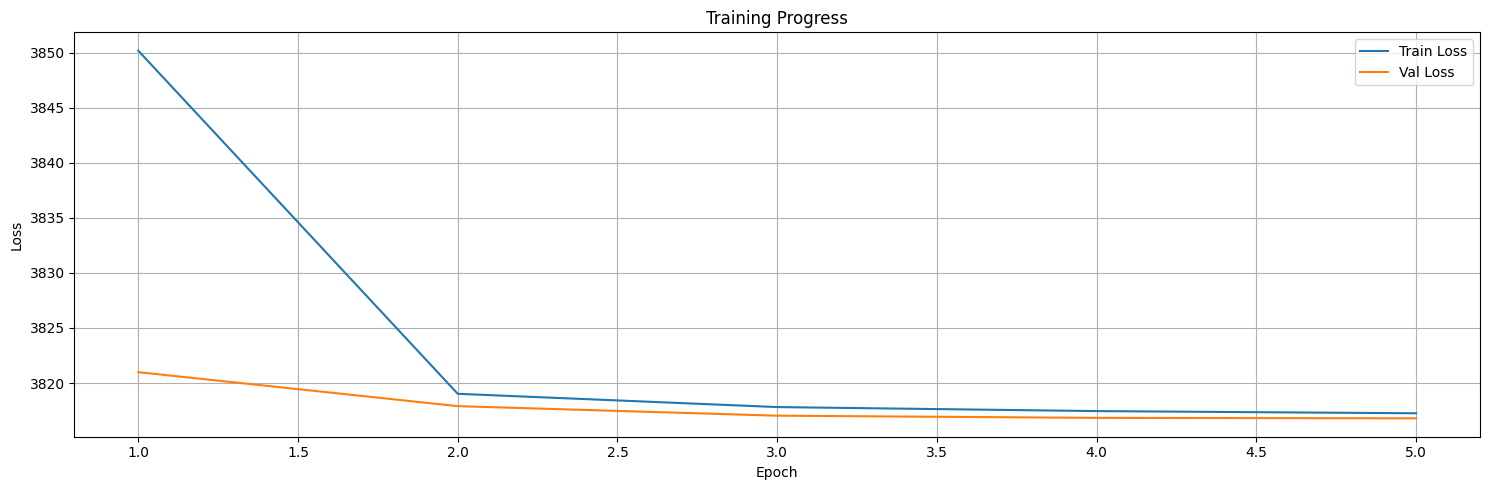

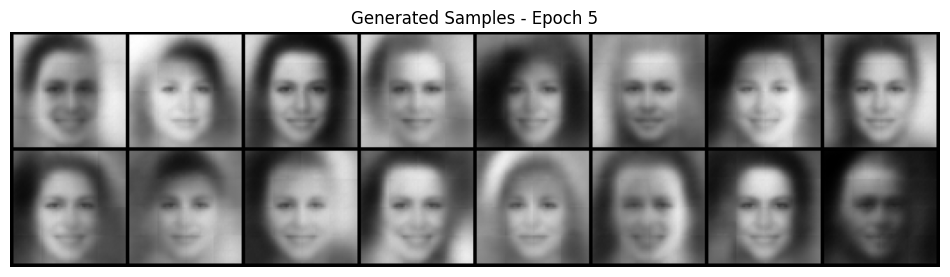

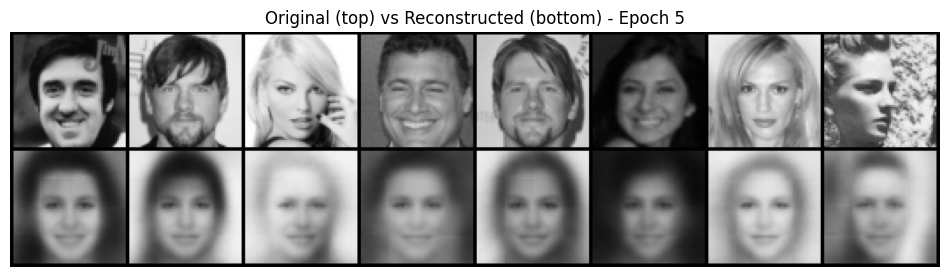

Epoch 5/5
Train Loss: 3817.2540
Val Loss: 3816.7934


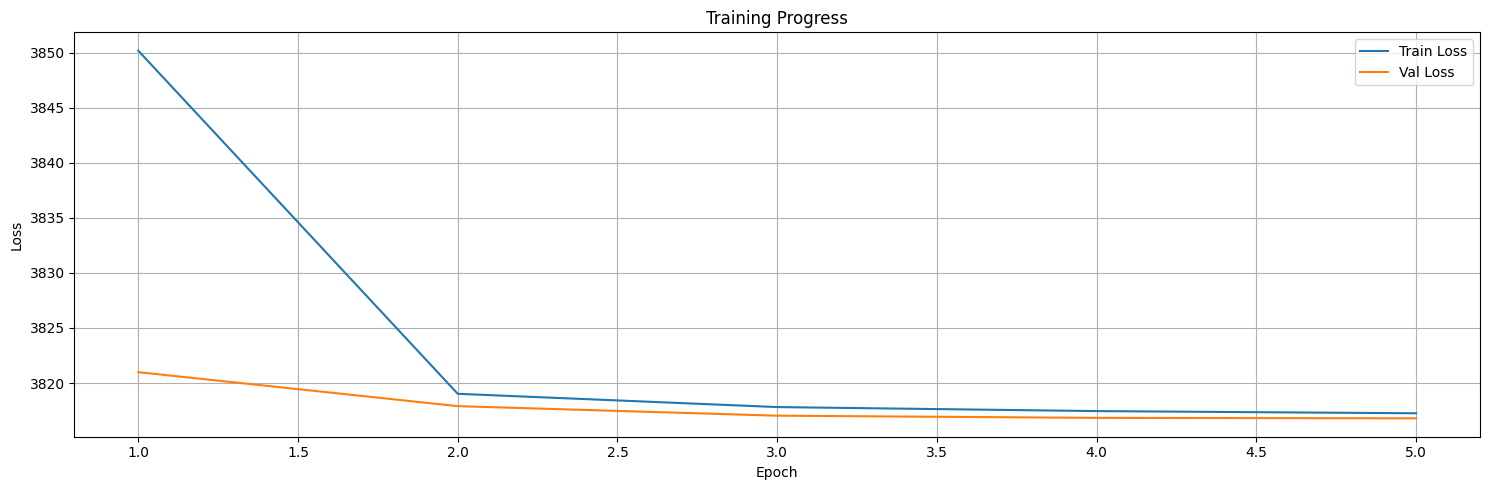

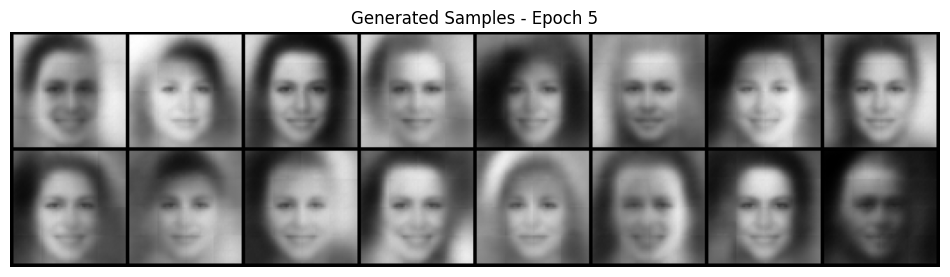

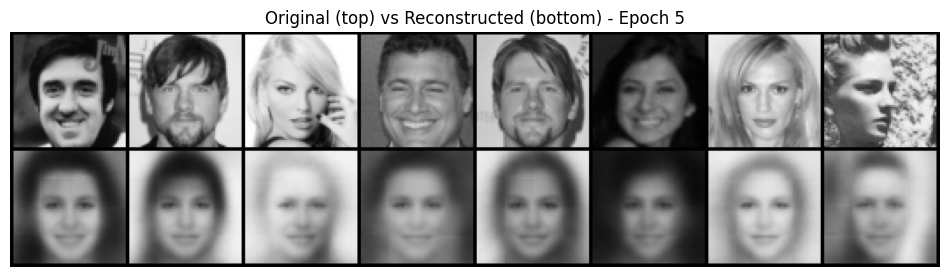

In [8]:
encoder = EncoderVAE(latent_dim=dimZ)
decoder = DecoderVAE(latent_dim=dimZ)

vae = VAE(encoder, decoder).to(device)
train_losses, val_losses = train_loop(
    vae, train_loader, val_loader, loss_function=loss_vae, epochs=5, device=device
)

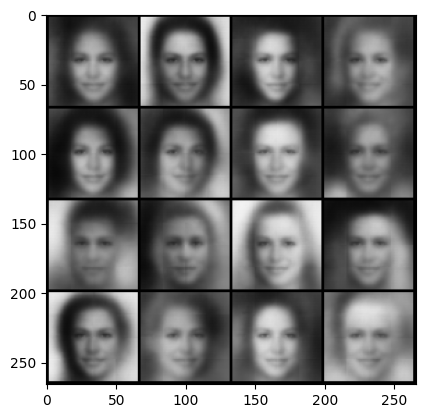

In [94]:
#!L
images, _ = list(islice(val_loader, 1))[0]
mu_gen, _, _ = vae(images.to(device))
reconstruction = mu_gen[:16].cpu().clamp(0, 1)

plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

And finally sample from VAE.

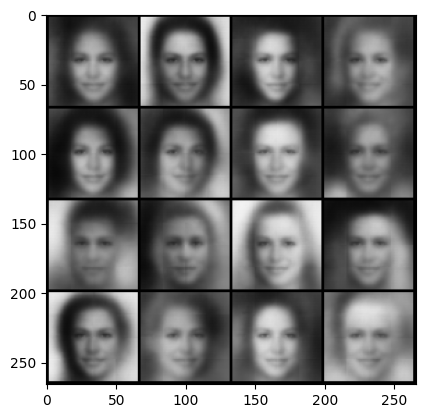

In [96]:
#!L
# TODO
# Sample some images from the learned distribution
# 1) Sample z ~ N(0,1)
# 2) Sample from N(decoder_mu(z), decoder_sigma(z))

sample = vae.generate(16, device=device)
plt.imshow(make_grid(reconstruction.cpu(), nrow=4).permute(1, 2, 0))

Even if in practice you do not see the much difference between AE and VAE, or VAE is even worse, the little bayesian inside you should be jumping for joy right now. 

In VAE you can truly sample from image distribution $p(x)$, while in AE there is no easy and correct way to do it. 

# Congrats! and Bonus

If you managed to tune your autoencoders to converge and learn something about the world, now it's time to make fun out of it. As you may have noticed, there are face attributes in dataset. We're interesting in "Smiling" column (index 31 of the attribute vector), but feel free to try others as well! Here is the first task:

1) Extract the "Smilling" attribute and create a two sets of images: 10 smiling faces and 10 non-smiling ones.

2) Compute latent representations for each image in "smiling" set and average those latent vectors. Do the same for "non-smiling" set. You have found **"vector representation"** of the "smile" and "no smile" attribute.

3) Compute the difference: "smile" vector minus "non-smile" vector.

3) Now check if **"feature arithmetics"** works. Sample a face without smile, encode it and add the diff from p. 3. Check if it works with both AE and VAE. 

<img src="linear.png" alt="linear">